In [9]:
# notebooks/01_vae_exploration.ipynb
import sys
import os
import torch
import matplotlib.pyplot as plt
import yaml

In [10]:
# Setup paths
sys.path.append(os.path.abspath('..'))
from src.vae.model import VAE
from src.vae.dataset import get_dataloader

In [11]:
# Load config
with open('../configs/vae.yaml', 'r') as f:
    config = yaml.safe_load(f)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [12]:
# Initialize model (assuming trained weights exist)
model = VAE(in_channels=1, latent_dim=config['model']['latent_dim']).to(device)

[VAE] Encoder output flattened dim: 1024


In [13]:
# model.load_state_dict(torch.load('../results/checkpoints/vae_final.pth')) # Uncomment if checkpoint exists
model.eval()

VAE(
  (encoder): Sequential(
    (0): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (1): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (2): Sequential(
      (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
    (3): Sequential(
      (0): Conv2d(128, 256, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): LeakyReLU(negative_slope=0.01)
    )
  )
  (fc_mu): Lin

In [14]:
# Visualize a batch
dataloader = get_dataloader(config)
data, labels = next(iter(dataloader))

In [15]:
with torch.no_grad():
    recon, mu, logvar = model(data.to(device))

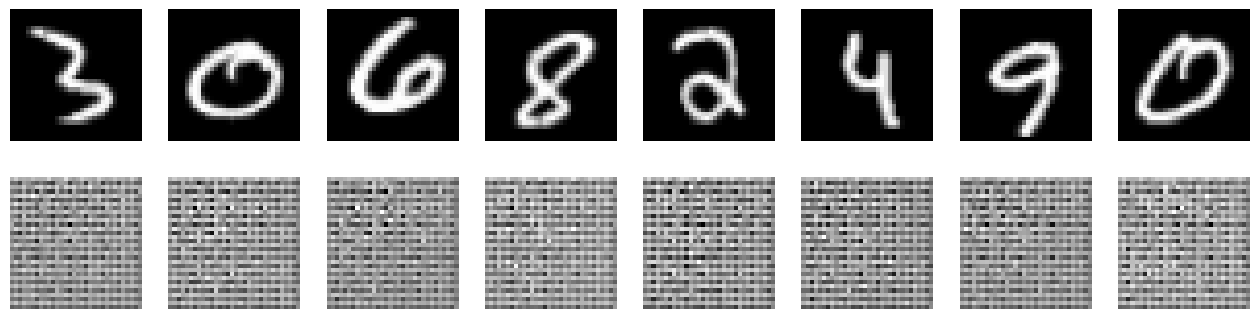

In [16]:
# Plot
fig, axes = plt.subplots(2, 8, figsize=(16, 4))
for i in range(8):
    axes[0, i].imshow(data[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(recon[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')
plt.show()